# GFDL-ESM4 sampling and mapping PDF bias by period

Recreates `gfdl_esm4_sampling_and_mapping_pdf_bias_by_period_1965_2021.png` with experiments on the six rows and depth ranges on the three columns. Curves show three 19-year periods. Each bias is the experiment's normalized oxygen-concentration PDF minus the fully sampled PDF.

In [1]:
from pathlib import Path
import os
import pickle

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib-db9274")
Path(os.environ["MPLCONFIGDIR"]).mkdir(parents=True, exist_ok=True)

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D

SOURCE_DIR = Path("/scratch/gpfs/LRGROUP/db9274/Variability_trends_EC/Paper_figures")
PAPER_DIR = Path("/scratch/gpfs/LRGROUP/db9274/Variability_trends_EC/Paper_figures_p2")
FIGURE_DIR = PAPER_DIR / "Figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_STEM = FIGURE_DIR / "gfdl_esm4_sampling_and_mapping_pdf_bias_by_period_1965_2021"
CACHE_PATH = SOURCE_DIR / "cache_gfdl_esm4_o2_concentration_distributions/gfdl_esm4_o2_concentration_pdfs_d11f09d98bfb2d0d.pkl"

CHUNKS = [(1965, 1983), (1984, 2002), (2003, 2021)]
DEPTH_DOMAINS = ["Global", "Upper 2000 m", "Below 2000 m"]
BIAS_ROWS = [
    "Subsampled",
    "Roach and Bindoff 2023",
    "Ito 2022 OI",
    "Ito 2024 NN potden",
    "Ito 2024 RF potden",
    "Gouretski 2024",
]
ROW_LABELS = {
    "Subsampled": "Subsampled",
    "Roach and Bindoff 2023": "Roach &\nBindoff (2023)",
    "Ito 2022 OI": "Ito\n(2022)",
    "Ito 2024 NN potden": "Ito NN\n(2024)",
    "Ito 2024 RF potden": "Ito RF\n(2024)",
    "Gouretski 2024": "Gouretski\n(2024)",
}
COLUMN_LABELS = {
    "Global": "Full column",
    "Upper 2000 m": "Upper 2000 m",
    "Below 2000 m": "Below 2000 m",
}
PERIOD_COLORS = {"1965-1983": "#5B2A86", "1984-2002": "#00A6A6", "2003-2021": "#E63973"}
PERIOD_LINESTYLES = {"1965-1983": "-", "1984-2002": "--", "2003-2021": "-."}
XLIM = (0.0, 350.0)
YLIM = (-0.8, 0.8)

plt.rcParams.update({
    "font.size": 9, "axes.titlesize": 10, "axes.labelsize": 9,
    "xtick.labelsize": 8, "ytick.labelsize": 8,
    "legend.fontsize": 8, "figure.dpi": 130, "savefig.dpi": 300,
    "pdf.fonttype": 42, "ps.fonttype": 42,
})

In [2]:
if not CACHE_PATH.exists():
    raise FileNotFoundError(f"Distribution cache not found: {CACHE_PATH}")
with CACHE_PATH.open("rb") as file:
    cached = pickle.load(file)
curves = cached["curves"]
print(f"Loaded {len(curves)} distribution curves from {CACHE_PATH}")

def pdf_bias_curve(period, domain, sample):
    x, full_pdf = curves[(period, domain, "Fully sampled")]
    sample_x, sample_pdf = curves[(period, domain, sample)]
    if not np.array_equal(sample_x, x):
        sample_pdf = np.interp(x, sample_x, sample_pdf, left=0.0, right=0.0)
    return x, sample_pdf - full_pdf

Loaded 63 distribution curves from /scratch/gpfs/LRGROUP/db9274/Variability_trends_EC/Paper_figures/cache_gfdl_esm4_o2_concentration_distributions/gfdl_esm4_o2_concentration_pdfs_d11f09d98bfb2d0d.pkl


Saved /scratch/gpfs/LRGROUP/db9274/Variability_trends_EC/Paper_figures_p2/Figures/gfdl_esm4_sampling_and_mapping_pdf_bias_by_period_1965_2021.pdf


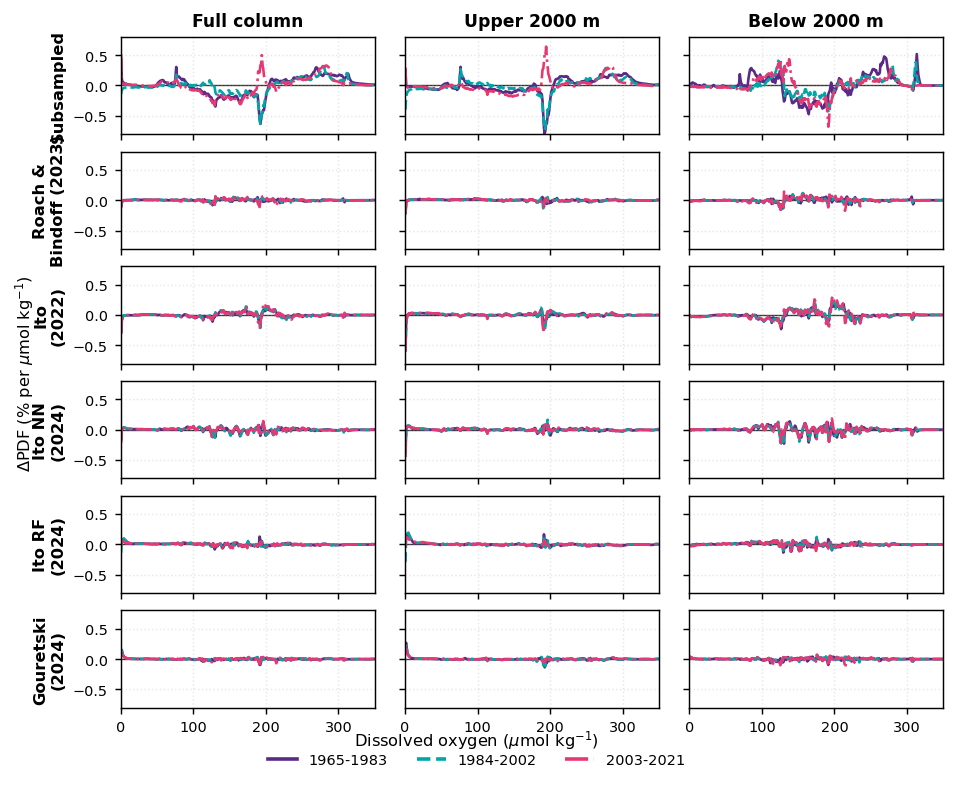

In [3]:
fig, axes = plt.subplots(
    len(BIAS_ROWS), len(DEPTH_DOMAINS), figsize=(7.4, 6.0),
    sharex=True, sharey=True, constrained_layout=False,
)

for row, sample_name in enumerate(BIAS_ROWS):
    for col, domain_name in enumerate(DEPTH_DOMAINS):
        ax = axes[row, col]
        for start, end in CHUNKS:
            period = f"{start}-{end}"
            x, bias = pdf_bias_curve(period, domain_name, sample_name)
            ax.plot(
                x, 100.0 * bias, color=PERIOD_COLORS[period],
                linestyle=PERIOD_LINESTYLES[period], lw=1.45, label=period,
            )
        ax.axhline(0.0, color="0.2", lw=0.75, zorder=0)
        ax.grid(True, ls=":", alpha=0.3)
        ax.set_xlim(*XLIM)
        ax.set_ylim(*YLIM)
        ax.set_xticks([0, 100, 200, 300])
        if row == 0:
            ax.set_title(COLUMN_LABELS[domain_name], fontsize=9.5, fontweight="bold")
        if col == 0:
            ax.set_ylabel(ROW_LABELS[sample_name], fontsize=9, fontweight="bold")
        if row == len(BIAS_ROWS) - 1:
            ax.tick_params(axis="x", labelbottom=True, bottom=True)

handles = [
    Line2D([0], [0], color=PERIOD_COLORS[f"{start}-{end}"],
           linestyle=PERIOD_LINESTYLES[f"{start}-{end}"], lw=2, label=f"{start}-{end}")
    for start, end in CHUNKS
]
fig.subplots_adjust(left=0.13, right=0.985, top=0.955, bottom=0.095, wspace=0.12, hspace=0.18)
fig.supylabel(r"$\Delta$PDF (% per $\mu$mol kg$^{-1}$)", x=0.018, y=0.525, fontsize=9)
fig.supxlabel(r"Dissolved oxygen ($\mu$mol kg$^{-1}$)", y=0.04, fontsize=9)
fig.legend(handles=handles, loc="lower center", ncol=3, frameon=False, bbox_to_anchor=(0.5, 0.002))

pdf_path = OUTPUT_STEM.with_suffix(".pdf")
fig.savefig(pdf_path, facecolor="white")
print(f"Saved {pdf_path}")
plt.show()